In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import norm
from sklearn.metrics import root_mean_squared_error
from matplotlib.gridspec import GridSpec


# Main Results

In [ ]:
def get_scores(journal, outcome = "Times cited (36mo)"):
    filename = f"open_access_results/{journal}_qualities_allpairs.csv"
    results = pd.read_csv(filename)
    results[['topic_novelty', 'topic_popularity', 'title_catchiness', 'generalizability', 'writing_quality', 'impact_of_results', 'subfield_popularity', 'technicality', 'meaningful_contributions' ,'journal_fit', 'applicability']] = results['response'].str.split(',', expand=True, n =10).apply(lambda lst: [x.strip() for x in lst])
    results['applicability'] = results['applicability'].str[:7]
    journal_df = pd.read_csv(f"open_access_journal_data/{journal}.csv")
    for col in ['topic_novelty', 'topic_popularity', 'title_catchiness', 'generalizability', 'writing_quality', 'impact_of_results', 'subfield_popularity', 'technicality', 'meaningful_contributions' ,'journal_fit', 'applicability']:

        transform_df = pd.concat([
            results.loc[results[col] == 'Paper 1', 'Article Title.1'],
            results.loc[results[col] == 'Paper 2', 'Article Title.2']
        ])

        rate_df = transform_df.value_counts().reset_index()
        rate_df.columns = ['Article Title', f'{col}_score']

        journal_df = pd.merge(journal_df, rate_df, on = 'Article Title', how = 'left').fillna(0)
    filename = f"open_access_results/{journal}_basic_allpairs.csv"
    results = pd.read_csv(filename)
    transform_df = pd.concat([
        results.loc[results['response'] == 'Paper 1', 'Article Title.1'],
        results.loc[results['response'] == 'Paper 2', 'Article Title.2']
        ])

    rate_df = transform_df.value_counts().reset_index()
    rate_df.columns = ['Article Title', 'risk_score']
    rate_df.sort_values('Article Title').head()
    rate_df = rate_df[['Article Title', 'risk_score']]

    journal_df = pd.merge(journal_df, rate_df, on = "Article Title", how = 'left').fillna(0)

    journal_df['log_authors'] = np.log(journal_df['Authors'])
    journal_df['log_pages'] = np.log(journal_df['Page length'])
    journal_df['review'] = np.where(journal_df['Article type'] == "Review", 1, 0) 
    journal_df['log_outcome'] = np.log(journal_df[outcome] + 1)

    journal_df.to_csv(f"open_access_results/{journal}_scores_allpairs.csv")

    return journal_df

def get_imputations(journal_df, seeds, outcome = "Times cited (36mo)", pred_type = "basic"):
    #journal_df = pd.read_csv(f"open_access_results/{journal}_scores_allpairs.csv")
    if pred_type == "basic":
        X = journal_df[['log_authors', 'log_pages', 'review', 'Self-archived', 'Open Access']]
    elif pred_type == "score_only":
        X = journal_df[['log_authors', 'log_pages', 'review', 'Self-archived', 'Open Access', 'risk_score']]
    elif pred_type == "qualities_only":
        X = journal_df[['log_authors', 'log_pages', 'review', 'Self-archived', 'topic_novelty_score',
       'topic_popularity_score', 'title_catchiness_score',
       'generalizability_score', 'writing_quality_score',
       'impact_of_results_score', 'subfield_popularity_score',
       'technicality_score', 'meaningful_contributions_score', 'applicability_score', 'Open Access']]
    elif pred_type == "all":
        X = journal_df[['log_authors', 'log_pages', 'review', 'Self-archived', 'topic_novelty_score',
       'topic_popularity_score', 'title_catchiness_score',
       'generalizability_score', 'writing_quality_score',
       'impact_of_results_score', 'subfield_popularity_score',
       'technicality_score', 'meaningful_contributions_score', 'applicability_score', 'risk_score', 'Open Access']]
        
    y = journal_df['log_outcome']

    # drop each observation, refit the random forest, and then get control and treatment inmputations 
    for i in journal_df.index:

        seed = int(seeds[i])

        X_withouti = X.drop(index = i)
        y_withouti = np.delete(y, i)

        model_withouti = RandomForestRegressor(
        n_estimators=100,
        oob_score=True,
        bootstrap=True,   # must be True for OOB
        random_state=seed
        )

        model_withouti.fit(X_withouti, y_withouti)

        observation_it = X.iloc[[i]]
        observation_it.loc[:,'Open Access'] = 1 

        observation_ic = X.iloc[[i]]
        observation_ic.loc[:,'Open Access'] = 0

        y_it = model_withouti.predict(observation_it)[0]
        y_ic = model_withouti.predict(observation_ic)[0]
    
        journal_df.loc[i, 'y_ic'] = y_ic
        journal_df.loc[i, 'y_it'] = y_it

    # save imputed data frames 
    journal_df.to_csv(f"open_access_results/{journal}_{pred_type}_imputations_allpairs.csv")

    return journal_df

def get_variance(journal_df, p):
    journal_df['m'] = p * journal_df['y_it'] + (1- p) * journal_df['y_ic']

    nc = len(journal_df) - sum(journal_df['Open Access'])
    nt = sum(journal_df['Open Access'])
    N = len(journal_df)

    ec2 = 1/nc * sum((1 - journal_df['Open Access']) * (journal_df['y_ic'] - journal_df['log_outcome'])**2)
    et2 = 1/nt * sum(journal_df['Open Access'] * (journal_df['y_it'] - journal_df['log_outcome'])**2)

    var_est = 1/N * (p/(1-p) * ec2 + (1-p)/p * et2 + 2 * (ec2 * et2)**0.5)
    return var_est

In [ ]:
# Table 5
rows = []
master_seed = 25
rng = np.random.default_rng(master_seed)
seed_list = iter(rng.integers(low=0, high=2**32 - 1, size =20))
ps = {'science': 0.12, 'neuro': 0.14, 'genetics': 0.49, 'faseb': 0.49, 'physio': 0.13}
sizes = {'science': 393, 'neuro': 278, 'genetics': 211, 'faseb': 165, 'physio': 201} 
for journal in ['science', 'neuro', 'genetics', 'faseb', 'physio']:
    print(journal)
    scores_df = get_scores(journal = journal)
    row = []
    for pred_type in ['basic', 'score_only', 'qualities_only', 'all']:
        print(pred_type)
        rng = np.random.default_rng(int(next(seed_list)))
        seeds = rng.integers(low=0, high=2**32 - 1, size =sizes[journal])
        journal_df = get_imputations(scores_df, seeds, outcome = "Times cited (36mo)", pred_type = pred_type)
        var_est = get_variance(journal_df, ps[journal])
        row.append(var_est)
    rows.append(row) 

results = pd.DataFrame(rows, index = ['Science', 'Neurophysiology', 'Genetics', 'FASEB','Applied Physiology'], columns =['Base Covariates', 'Base + Rating Score', 'Base + 10 Qualities', 'Base + Both'] )
print(np.sqrt(results))

science
basic
score_only
qualities_only
all
neuro
basic
score_only
qualities_only
all
genetics
basic
score_only
qualities_only
all
faseb
basic
score_only
qualities_only
all
physio
basic
score_only
qualities_only
all
                    Base Covariates  Base + Rating Score  Base + 10 Qualities  \
Science                    0.122736             0.118597             0.113561   
Neurophysiology            0.129924             0.118215             0.113154   
Genetics                   0.111044             0.108498             0.098524   
FASEB                      0.106620             0.102744             0.097866   
Applied Physiology         0.170707             0.178610             0.174439   

                    Base + Both  
Science                0.101087  
Neurophysiology        0.109339  
Genetics               0.098770  
FASEB                  0.093569  
Applied Physiology     0.164317  


In [3]:
# get results now after first one has run 

rows = []
ps = {'science': 0.12, 'neuro': 0.14, 'genetics': 0.49, 'faseb': 0.49, 'physio': 0.13}
sizes = {'science': 393, 'neuro': 278, 'genetics': 211, 'faseb': 165, 'physio': 201} 
for journal in ['science', 'neuro', 'genetics', 'faseb', 'physio']:
    print(journal)
    scores_df = pd.read_csv(f"open_access_results/{journal}_scores_allpairs.csv")
    row = []
    for pred_type in ['basic', 'score_only', 'qualities_only', 'all']:
        print(pred_type)
        journal_df = pd.read_csv(f"open_access_results/{journal}_{pred_type}_imputations_allpairs.csv")
        var_est = get_variance(journal_df, ps[journal])
        row.append(var_est)
    rows.append(row) 

results = pd.DataFrame(rows, index = ['Science', 'Neurophysiology', 'Genetics', 'FASEB','Applied Physiology'], columns =['Base Covariates', 'Base + Citation Score', 'Base + 10 Qualities', 'Base + Both'] )
print(np.sqrt(results))

science
basic
score_only
qualities_only
all
neuro
basic
score_only
qualities_only
all
genetics
basic
score_only
qualities_only
all
faseb
basic
score_only
qualities_only
all
physio
basic
score_only
qualities_only
all
                    Base Covariates  Base + Citation Score  \
Science                    0.122736               0.118597   
Neurophysiology            0.129924               0.118215   
Genetics                   0.111044               0.108498   
FASEB                      0.106620               0.102744   
Applied Physiology         0.170707               0.178610   

                    Base + 10 Qualities  Base + Both  
Science                        0.113561     0.101087  
Neurophysiology                0.113154     0.109339  
Genetics                       0.098524     0.098770  
FASEB                          0.097866     0.093569  
Applied Physiology             0.174439     0.164317  


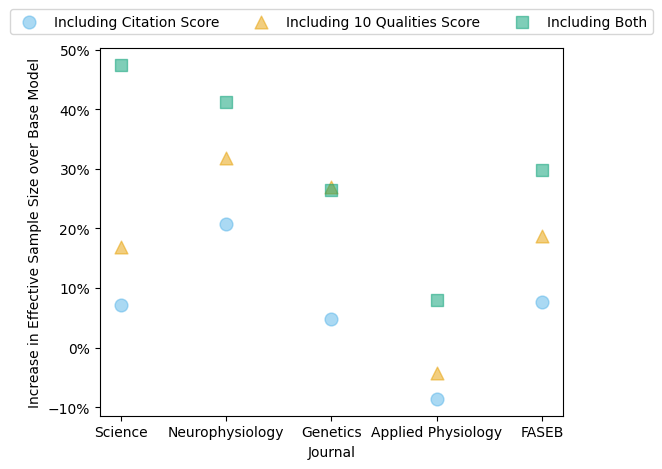

In [ ]:
# Figure 1
from matplotlib.ticker import PercentFormatter


results = results.iloc[[0, 1, 2, 4, 3]]



ratios = (results.iloc[:, 1:].rdiv(results.iloc[:, 0], axis=0) - 1) * 100

fig, ax = plt.subplots()


style = {
    "Including Citation Score":    {"color": '#56B4E9',     "marker": "o"},
    "Including 10 Qualities Score": {"color": '#E69F00',  "marker": "^"},
    "Including Both": {"color": "#009E73",   "marker": "s"},
}

for col, label in zip(ratios.columns, style):
    ax.scatter(
        ratios.index,
        ratios[col],
        color=style[label]["color"],
        marker=style[label]["marker"],
        label=label,
        alpha = 0.5,
        s=85 
    )

ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_xlabel("Journal")
ax.set_ylabel("Increase in Effective Sample Size over Base Model")

plt.tight_layout()
plt.show()
fig.savefig("oa_results.jpg", bbox_inches="tight", dpi = 600)

In [16]:
# get treatment effect estimates 
def get_treatment_est(journal_df,p):
    journal_df['m'] = p * journal_df['y_it'] + (1- p) * journal_df['y_ic']
    N = len(journal_df)
    treatment_est = 1/N * sum((journal_df['Open Access'] * (journal_df['log_outcome'] - journal_df['m']))/p) - 1/N * sum(((1-journal_df['Open Access']) * (journal_df['log_outcome'] - journal_df['m']))/(1-p))
    return treatment_est


ps = {'science': 0.12, 'neuro': 0.14, 'genetics': 0.49, 'faseb': 0.49, 'physio': 0.13}
rows2 = []
for journal in ['science', 'neuro', 'genetics', 'faseb', 'physio']:
    row2 = []
    for pred_type in ['basic', 'score_only', 'qualities_only', 'all']:
        journal_df = pd.read_csv(f"open_access_results/{journal}_{pred_type}_imputations_allpairs.csv")
        treatment_est = get_treatment_est(journal_df, ps[journal])
        row2.append(treatment_est)
    rows2.append(row2) 

treat_results = pd.DataFrame(rows2, index = ['Science', 'Neurophysiology', 'Genetics', 'FASEB','Applied Physiology'], columns =['Base Covariates', 'Base + Citation Score', 'Base + 10 Qualities', 'Base + Both'] )
print(treat_results)

                    Base Covariates  Base + Citation Score  \
Science                    0.175647               0.314066   
Neurophysiology           -0.104137              -0.097654   
Genetics                  -0.077808               0.045157   
FASEB                      0.113243               0.169563   
Applied Physiology        -0.182062               0.164089   

                    Base + 10 Qualities  Base + Both  
Science                        0.121093     0.160879  
Neurophysiology               -0.052662    -0.069905  
Genetics                      -0.120211    -0.067982  
FASEB                          0.145470     0.136408  
Applied Physiology             0.006151     0.044362  


In [27]:
np.sqrt(results)

,Base Covariates,Base + Citation Score,Base + 10 Qualities,Base + Both
Science,0.122736,0.118597,0.113561,0.101087
Neurophysiology,0.129924,0.118215,0.113154,0.109339
Genetics,0.111044,0.108498,0.098524,0.098770
Applied Physiology,0.170707,0.178610,0.174439,0.164317
FASEB,0.106620,0.102744,0.097866,0.093569


In [ ]:
print(treat_results/np.sqrt(results))

,Base Covariates,Base + Citation Score,Base + 10 Qualities,Base + Both
Applied Physiology,-1.066517,0.918702,0.035264,0.269978
FASEB,1.062114,1.650347,1.486416,1.457843
Genetics,-0.700693,0.416202,-1.220117,-0.688284
Neurophysiology,-0.801522,-0.826071,-0.465403,-0.639343
Science,1.431092,2.648175,1.066321,1.591501


In [ ]:
# p values
from scipy.stats import norm
zs = treat_results/np.sqrt(results)
pvals = 2 * (1-norm.cdf(np.abs(zs)))
print(pvals)

[[0.28618988 0.35825127 0.97186938 0.78717742]
 [0.28818412 0.09887193 0.13716921 0.14488388]
 [0.48349441 0.6772619  0.22242046 0.49127364]
 [0.42282949 0.40876387 0.64164294 0.52259998]
 [0.15240372 0.00809277 0.28627837 0.11149684]]


In [ ]:
# Fisher's method
import math
from scipy.stats import chi2
for i, column in enumerate(zip(*pvals), start=1):
    chi_stat = -2 * sum(math.log(x) for x in column)
    print(f"Column {i} test stat = {chi_stat}")
    print(f"Column {i} p value = {chi2.sf(chi_stat, 10)}")

Column 1 test stat = 11.927958987165763
Column 1 p value = 0.28990688344901766
Column 2 test stat = 18.883100480359836
Column 2 p value = 0.041772853195945266
Column 3 test stat = 10.425546995754502
Column 3 p value = 0.4039844250628302
Column 4 test stat = 11.44915259181707
Column 4 p value = 0.3236112565383339


# Supplementary Information

#### Correlation of Adjusted Scores with Outcome (Table 2)

In [ ]:
# Correlations between scores and outcome 
files = {
    "Science": "open_access_results/science_scores_allpairs.csv",
    "Neuro": "open_access_results/neuro_scores_allpairs.csv",
    "Genetics": "open_access_results/genetics_scores_allpairs.csv",
    "FASEB": "open_access_results/faseb_scores_allpairs.csv",
    "Physio": "open_access_results/physio_scores_allpairs.csv",
}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

cols = ['risk_score', 'topic_popularity_score', 'title_catchiness_score',
       'generalizability_score', 'writing_quality_score',
       'impact_of_results_score', 'subfield_popularity_score',
       'technicality_score', 'meaningful_contributions_score', 'applicability_score']

target = "log_outcome"

corr_table = pd.DataFrame({
    name: [df[col].corr(df[target]) for col in cols]
    for name, df in dfs.items()
}, index=cols)

corr_table.index.name = "Variable"
corr_table = corr_table.round(3)

print(corr_table.T)

Variable  risk_score  topic_popularity_score  title_catchiness_score  \
Science        0.482                   0.086                   0.158   
Neuro          0.380                   0.165                   0.278   
Genetics       0.341                   0.131                   0.140   
FASEB          0.408                  -0.049                  -0.010   
Physio         0.512                   0.032                   0.258   

Variable  generalizability_score  writing_quality_score  \
Science                    0.222                  0.389   
Neuro                      0.196                  0.337   
Genetics                   0.282                  0.034   
FASEB                      0.290                  0.117   
Physio                     0.344                  0.326   

Variable  impact_of_results_score  subfield_popularity_score  \
Science                     0.270                     -0.140   
Neuro                       0.249                     -0.055   
Genetics            

In [14]:
latex_table = corr_table.to_latex(
    float_format="%.3f",
    caption="Correlation coefficients with target variable",
    label="tab:correlations"
)

print(latex_table)

\begin{table}
\caption{Correlation coefficients with target variable}
\label{tab:correlations}
\begin{tabular}{lrrrrr}
\toprule
 & Science & Neuro & Genetics & FASEB & Physio \\
Variable &  &  &  &  &  \\
\midrule
risk_score & 0.482 & 0.380 & 0.341 & 0.408 & 0.512 \\
topic_popularity_score & 0.086 & 0.165 & 0.131 & -0.049 & 0.032 \\
title_catchiness_score & 0.158 & 0.278 & 0.140 & -0.010 & 0.258 \\
generalizability_score & 0.222 & 0.196 & 0.282 & 0.290 & 0.344 \\
writing_quality_score & 0.389 & 0.337 & 0.034 & 0.117 & 0.326 \\
impact_of_results_score & 0.270 & 0.249 & 0.308 & 0.258 & 0.234 \\
subfield_popularity_score & -0.140 & -0.055 & 0.059 & -0.148 & -0.004 \\
technicality_score & -0.072 & -0.212 & -0.255 & -0.176 & -0.284 \\
meaningful_contributions_score & 0.221 & 0.339 & 0.330 & 0.204 & 0.438 \\
applicability_score & 0.248 & 0.115 & 0.287 & 0.175 & 0.132 \\
\bottomrule
\end{tabular}
\end{table}



#### Histograms of Adjusted Pair Score (Figure 2)

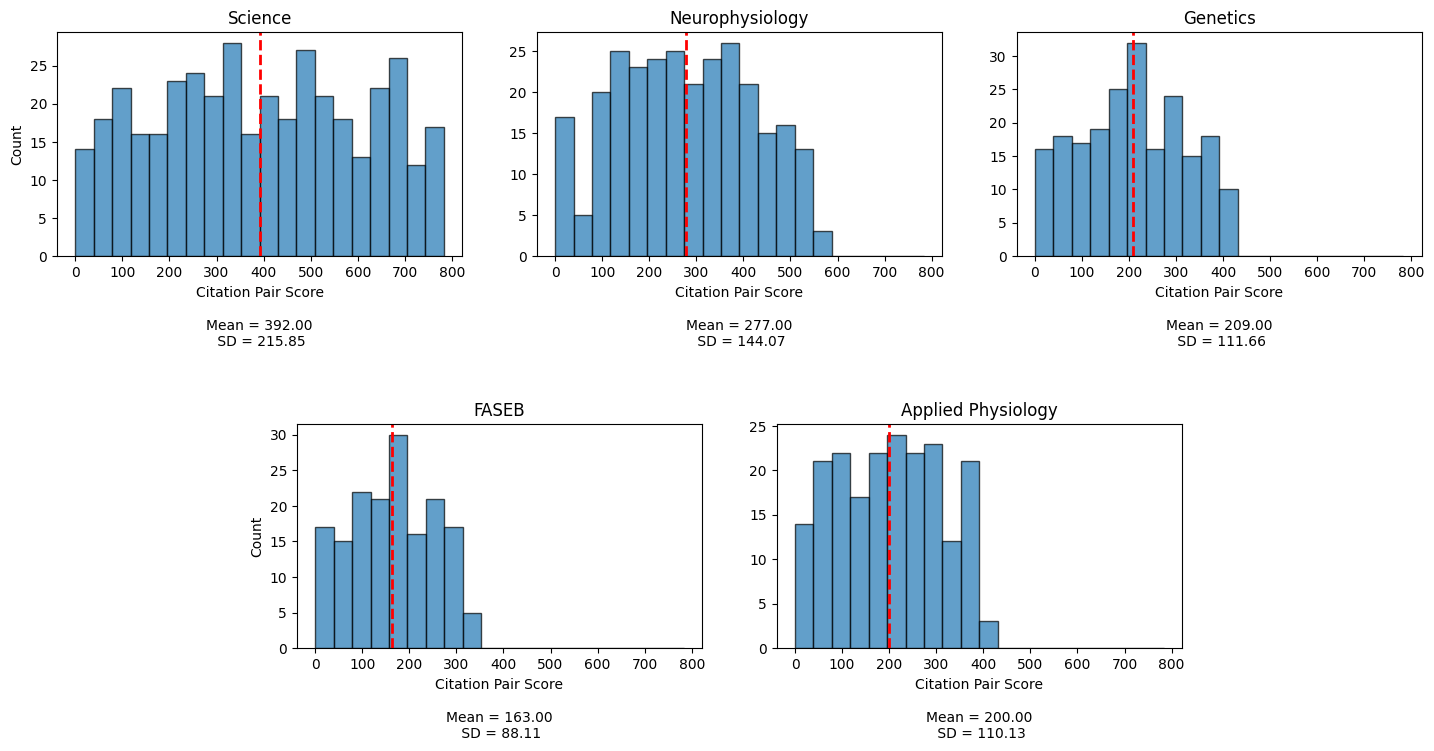

In [3]:
files = {
    "Science": "open_access_results/science_scores_allpairs.csv",
    "Neurophysiology": "open_access_results/neuro_scores_allpairs.csv",
    "Genetics": "open_access_results/genetics_scores_allpairs.csv",
    "FASEB": "open_access_results/faseb_scores_allpairs.csv",
    "Applied Physiology": "open_access_results/physio_scores_allpairs.csv",
}

dfs = {name: pd.read_csv(path) for name, path in files.items()}


variable = "risk_score"  


all_data = pd.concat([df[variable] for df in dfs.values()]).dropna()
bins = np.histogram_bin_edges(all_data, bins=20)


fig = plt.figure(figsize=(15, 8))
gs = GridSpec(2, 6, figure=fig)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
]


for ax, (title, df) in zip(axes, dfs.items()):
    data = df[variable].dropna()

    mean = data.mean()
    std = data.std()

    ax.hist(data, bins=bins, edgecolor="black", alpha=0.7)
    ax.axvline(mean, color="red", linestyle="--", linewidth=2)

    ax.set_title(title)
    ax.set_xlabel("Citation Pair Score")

    ax.text(
        0.5, -0.28,
        f"Mean = {mean:.2f}\n SD = {std:.2f}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10
    )

axes[0].set_ylabel("Count")
axes[3].set_ylabel("Count")

# Adjust spacing
plt.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.92,
    bottom=0.15,
    wspace=0.45,
    hspace=0.75,
)

fig.savefig("oa_hist.pdf", bbox_inches="tight")
fig.savefig("oa_hist.jpg", bbox_inches="tight", dpi = 600)
plt.show()

# Appendix C

#### RMSEs from full model (Table 4)

In [4]:
# RMSEs from full model 

def get_rf_rmse(journal, seed, outcome = "Times cited (36mo)", pred_type = "basic"):
    journal_df = pd.read_csv(f"open_access_results/{journal}_scores_allpairs.csv")

    journal_df['log_authors'] = np.log(journal_df['Authors'])
    journal_df['log_pages'] = np.log(journal_df['Page length'])
    journal_df['review'] = np.where(journal_df['Article type'] == "Review", 1, 0) 
    journal_df['log_outcome'] = np.log(journal_df[outcome] + 1)

    if pred_type == "basic":
        X = journal_df[['log_authors', 'log_pages', 'review', 'Self-archived', 'Open Access']]
    elif pred_type == "score_only":
        X = journal_df[['log_authors', 'log_pages', 'review', 'Self-archived', 'Open Access', 'risk_score']]
    elif pred_type == "qualities_only":
        X = journal_df[['log_authors', 'log_pages', 'review', 'Self-archived', 'topic_novelty_score',
       'topic_popularity_score', 'title_catchiness_score',
       'generalizability_score', 'writing_quality_score',
       'impact_of_results_score', 'subfield_popularity_score',
       'technicality_score', 'meaningful_contributions_score', 'applicability_score', 'Open Access']]
    elif pred_type == "all":
        X = journal_df[['log_authors', 'log_pages', 'review', 'Self-archived', 'topic_novelty_score',
       'topic_popularity_score', 'title_catchiness_score',
       'generalizability_score', 'writing_quality_score',
       'impact_of_results_score', 'subfield_popularity_score',
       'technicality_score', 'meaningful_contributions_score', 'applicability_score', 'risk_score', 'Open Access']]
        
    y = journal_df['log_outcome']

    rf_model = RandomForestRegressor(
        n_estimators=100,
        oob_score=True,
        bootstrap=True,   # must be True for OOB
        random_state=seed
        )
    rf_model.fit(X, y)

    y_oobs = rf_model.oob_prediction_
    return y, y_oobs


# save y and y_oobs somewhere
results_all = []
rng = np.random.default_rng(948)
seeds = iter(rng.integers(low=0, high=2**32 - 1, size = 20))
for i, journal in enumerate(['science', 'neuro', 'genetics', 'faseb', 'physio']):
    row = []
    for j, pred_type in enumerate(['basic', 'score_only', 'qualities_only', 'all']):
        y, y_oobs = get_rf_rmse(journal = journal, pred_type = pred_type, seed= next(seeds))
        row.append((y,y_oobs))
    results_all.append(row)

        

In [5]:
rmses = []
for i, journal in enumerate(['science', 'neuro', 'genetics', 'faseb', 'physio']):
    row = []
    for j, pred_type in enumerate(['basic', 'score_only', 'qualities_only', 'all']):
        y, y_oobs = results_all[i][j]
        rmse = root_mean_squared_error(y, y_oobs)
        row.append(rmse)
    rmses.append(row)

rmse_results = pd.DataFrame(rmses, index = ['Science', 'Neurophysiology', 'Genetics', 'FASEB','Applied Physiology'], columns =['Base Covariates', 'Base + Rating Score', 'Base + 10 Qualities', 'Base + Both'] )
print(rmse_results)

                    Base Covariates  Base + Rating Score  Base + 10 Qualities  \
Science                    0.817365             0.762373             0.712970   
Neurophysiology            0.702082             0.628679             0.632725   
Genetics                   0.808082             0.789301             0.727796   
FASEB                      0.689600             0.659735             0.630921   
Applied Physiology         0.829310             0.730556             0.722631   

                    Base + Both  
Science                0.686301  
Neurophysiology        0.610809  
Genetics               0.722733  
FASEB                  0.597224  
Applied Physiology     0.686743  


#### Combined Regressions (Table 3)

In [3]:
dfs = []

for journal in ['science', 'neuro', 'genetics', 'faseb', 'physio']:
    journal_df = pd.read_csv(f"open_access_results/{journal}_scores_allpairs.csv")
    for col in ['topic_novelty_score',
       'topic_popularity_score', 'title_catchiness_score',
       'generalizability_score', 'writing_quality_score',
       'impact_of_results_score', 'subfield_popularity_score',
       'technicality_score', 'meaningful_contributions_score', 'applicability_score', 'risk_score']:
        journal_df[col + "_adj"] = journal_df[col]/((len(journal_df) - 1) * 2)

    dfs.append(journal_df)
combined_df = pd.concat(dfs, ignore_index=True)

In [7]:
combined_df = combined_df[['Journal', 'log_authors', 'log_pages', 'review', 'Self-archived', 'topic_novelty_score_adj',
       'topic_popularity_score_adj', 'title_catchiness_score_adj',
       'generalizability_score_adj', 'writing_quality_score_adj',
       'impact_of_results_score_adj', 'subfield_popularity_score_adj',
       'technicality_score_adj', 'meaningful_contributions_score_adj', 'applicability_score_adj', 'risk_score_adj', 'Open Access', 'log_outcome']]
combined_df_encoded = pd.get_dummies(combined_df, columns=["Journal"], drop_first=True)

basicX = combined_df_encoded[['Journal_Genetics',
       'Journal_J. Appl. Physiol.', 'Journal_J. Neurophysiol.',
       'Journal_Science', 'log_authors', 'log_pages', 'review', 'Self-archived']]
y = combined_df_encoded['log_outcome']

rf = RandomForestRegressor(
        oob_score = True,
        bootstrap = True,
        random_state=9382,
        n_jobs=-1
    )

rf.fit(basicX, y)

combined_df_encoded['oob_preds'] = rf.oob_prediction_

X5 = combined_df_encoded.drop(columns = ['log_outcome'])

import statsmodels.api as sm

X5= sm.add_constant(X5.astype(float))

model5 = sm.OLS(y, X5).fit()

print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:            log_outcome   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     120.2
Date:                Wed, 08 Jul 2026   Prob (F-statistic):          2.39e-279
Time:                        09:53:53   Log-Likelihood:                -1193.8
No. Observations:                1246   AIC:                             2432.
Df Residuals:                    1224   BIC:                             2545.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

In [ ]:

# OLD MODEL WITHOUT OOB PREDS 
combined_df = combined_df[['Journal', 'log_authors', 'log_pages', 'review', 'Self-archived', 'topic_novelty_score_adj',
       'topic_popularity_score_adj', 'title_catchiness_score_adj',
       'generalizability_score_adj', 'writing_quality_score_adj',
       'impact_of_results_score_adj', 'subfield_popularity_score_adj',
       'technicality_score_adj', 'meaningful_contributions_score_adj', 'applicability_score_adj', 'risk_score_adj', 'Open Access', 'log_outcome']]

combined_df_encoded = pd.get_dummies(combined_df, columns=["Journal"], drop_first=True)
X4 = combined_df_encoded.drop(columns = ['log_outcome']) 


y = combined_df_encoded['log_outcome']

import statsmodels.api as sm

X4= sm.add_constant(X4.astype(float))

model4 = sm.OLS(y, X4).fit()

print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:            log_outcome   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                     124.5
Date:                Fri, 03 Jul 2026   Prob (F-statistic):          6.99e-278
Time:                        10:22:18   Log-Likelihood:                -1199.8
No. Observations:                1246   AIC:                             2442.
Df Residuals:                    1225   BIC:                             2549.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

In [47]:
summary = model4.summary2()
df = summary.tables[1].copy()
df = df[["Coef.", "Std.Err.", "P>|t|"]]
df = df.round(3)


print(df.to_latex(
    float_format="%.3f",
    column_format="lccc",
    escape=False
))

\begin{tabular}{lccc}
\toprule
 & Coef. & Std.Err. & P>|t| \\
\midrule
const & 21.192 & 10.826 & 0.051 \\
log_authors & 0.234 & 0.031 & 0.000 \\
log_pages & 0.248 & 0.061 & 0.000 \\
review & 0.057 & 0.090 & 0.531 \\
Self-archived & 0.009 & 0.092 & 0.926 \\
topic_novelty_score_adj & -45.050 & 22.889 & 0.049 \\
topic_popularity_score_adj & 0.930 & 3.229 & 0.773 \\
title_catchiness_score_adj & -0.420 & 0.148 & 0.005 \\
generalizability_score_adj & 0.399 & 0.132 & 0.003 \\
writing_quality_score_adj & 0.668 & 0.190 & 0.000 \\
impact_of_results_score_adj & -0.005 & 0.161 & 0.977 \\
subfield_popularity_score_adj & 1.195 & 0.455 & 0.009 \\
technicality_score_adj & 0.985 & 0.211 & 0.000 \\
meaningful_contributions_score_adj & 0.649 & 0.269 & 0.016 \\
applicability_score_adj & 0.415 & 0.179 & 0.020 \\
risk_score_adj & 1.052 & 0.115 & 0.000 \\
Open Access & 0.048 & 0.046 & 0.299 \\
Journal_Genetics & -0.437 & 0.069 & 0.000 \\
Journal_J. Appl. Physiol. & -0.481 & 0.072 & 0.000 \\
Journal_J. Neurop

####  Variable Importance (for Limitations section)

In [9]:
def get_var_importance(journal, outcome = "Times cited (36mo)"): 
    journal_df = pd.read_csv(f"open_access_results/{journal}_scores_allpairs.csv")
    for col in ['topic_novelty_score',
       'topic_popularity_score', 'title_catchiness_score',
       'generalizability_score', 'writing_quality_score',
       'impact_of_results_score', 'subfield_popularity_score',
       'technicality_score', 'meaningful_contributions_score', 'applicability_score', 'risk_score']:
        journal_df[col + "_adj"] = journal_df[col]/((len(journal_df) - 1) * 2)

    journal_df['log_authors'] = np.log(journal_df['Authors'])
    journal_df['log_pages'] = np.log(journal_df['Page length'])
    journal_df['review'] = np.where(journal_df['Article type'] == "Review", 1, 0) 
    journal_df['log_outcome'] = np.log(journal_df[outcome] + 1)

    X = journal_df[['log_authors', 'log_pages', 'review', 'Self-archived', 'topic_novelty_score_adj',
       'topic_popularity_score_adj', 'title_catchiness_score_adj',
       'generalizability_score_adj', 'writing_quality_score_adj',
       'impact_of_results_score_adj', 'subfield_popularity_score_adj',
       'technicality_score_adj', 'meaningful_contributions_score_adj', 'applicability_score_adj']]
    y = journal_df['log_outcome']

    rf = RandomForestRegressor(
        n_estimators=500,
        oob_score=True,
        bootstrap=True,   
        random_state=42
    )

    rf.fit(X, y)
    importances = rf.feature_importances_

    importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)
    return importance_df

full = pd.DataFrame({'order': range(1,15 )})
for journal in ['science', 'neuro', 'genetics', 'faseb', 'physio']:
    importance_df = get_var_importance(journal)
    importance_df.columns = [f'{journal}_feature', f'{journal}_importance']
    importance_df['order'] = range(1, 15)
    full = full.merge(importance_df, on = 'order', how = 'left')

full

,order,science_feature,science_importance,neuro_feature,neuro_importance,genetics_feature,genetics_importance,faseb_feature,faseb_importance,physio_feature,physio_importance
0,1,writing_quality_score_adj,0.220758,writing_quality_score_adj,0.174092,generalizability_score_adj,0.178638,generalizability_score_adj,0.181639,meaningful_contributions_score_adj,0.277569
1,2,impact_of_results_score_adj,0.149610,title_catchiness_score_adj,0.167385,meaningful_contributions_score_adj,0.127331,impact_of_results_score_adj,0.116059,writing_quality_score_adj,0.117379
2,3,log_authors,0.135191,meaningful_contributions_score_adj,0.111364,title_catchiness_score_adj,0.125722,applicability_score_adj,0.114828,applicability_score_adj,0.090008
3,4,applicability_score_adj,0.096972,subfield_popularity_score_adj,0.102767,technicality_score_adj,0.100362,title_catchiness_score_adj,0.086498,generalizability_score_adj,0.085096
4,5,log_pages,0.080229,generalizability_score_adj,0.091823,subfield_popularity_score_adj,0.094954,writing_quality_score_adj,0.086415,title_catchiness_score_adj,0.077678
5,6,generalizability_score_adj,0.070084,impact_of_results_score_adj,0.089973,applicability_score_adj,0.092487,log_pages,0.086050,subfield_popularity_score_adj,0.076404
6,7,subfield_popularity_score_adj,0.069806,applicability_score_adj,0.062313,impact_of_results_score_adj,0.078828,subfield_popularity_score_adj,0.083604,impact_of_results_score_adj,0.067605
7,8,meaningful_contributions_score_adj,0.052907,technicality_score_adj,0.060973,log_pages,0.070059,technicality_score_adj,0.070814,technicality_score_adj,0.063933
8,9,technicality_score_adj,0.049797,log_pages,0.059648,writing_quality_score_adj,0.060036,meaningful_contributions_score_adj,0.070790,log_pages,0.062606
9,10,title_catchiness_score_adj,0.048752,log_authors,0.049767,log_authors,0.059890,log_authors,0.064767,log_authors,0.041788


In [10]:
all_journals = pd.DataFrame()

for journal in ['science', 'neuro', 'genetics', 'faseb', 'physio']:
    journal_df = pd.read_csv(f"open_access_results/{journal}_scores_allpairs.csv")
    for col in ['topic_novelty_score',
       'topic_popularity_score', 'title_catchiness_score',
       'generalizability_score', 'writing_quality_score',
       'impact_of_results_score', 'subfield_popularity_score',
       'technicality_score', 'meaningful_contributions_score', 'applicability_score', 'risk_score']:
        journal_df[col + "_adj"] = journal_df[col]/((len(journal_df) - 1) * 2)

    journal_df['log_authors'] = np.log(journal_df['Authors'])
    journal_df['log_pages'] = np.log(journal_df['Page length'])
    journal_df['review'] = np.where(journal_df['Article type'] == "Review", 1, 0) 
    journal_df['log_outcome'] = np.log(journal_df["Times cited (36mo)"] + 1)
    journal_df['journal'] = journal

    all_journals = pd.concat([all_journals, journal_df])

all_journals['science'] = np.where(all_journals['journal'] == "science", 1, 0)
all_journals['neuro'] = np.where(all_journals['journal'] == "neuro", 1, 0)
all_journals['genetics'] = np.where(all_journals['journal'] == "genetics", 1, 0)
all_journals['faseb'] = np.where(all_journals['journal'] == "faseb", 1, 0)


X = all_journals[['science', 'neuro', 'genetics', 'faseb', 'log_authors', 'log_pages', 'review', 'Self-archived', 'topic_novelty_score_adj',
       'topic_popularity_score_adj', 'title_catchiness_score_adj',
       'generalizability_score_adj', 'writing_quality_score_adj',
       'impact_of_results_score_adj', 'subfield_popularity_score_adj',
       'technicality_score_adj', 'meaningful_contributions_score_adj', 'applicability_score_adj']]
y = all_journals['log_outcome']

rf = RandomForestRegressor(
        n_estimators=100,
        oob_score=True,
        bootstrap=True,   
        random_state=42
    )

rf.fit(X, y)
importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(importance_df)

                               feature  importance
0                              science    0.501337
12           writing_quality_score_adj    0.069771
16  meaningful_contributions_score_adj    0.064081
13         impact_of_results_score_adj    0.048422
11          generalizability_score_adj    0.047184
17             applicability_score_adj    0.040539
4                          log_authors    0.040298
10          title_catchiness_score_adj    0.039086
14       subfield_popularity_score_adj    0.037387
5                            log_pages    0.033492
15              technicality_score_adj    0.032640
3                                faseb    0.029081
9           topic_popularity_score_adj    0.007472
1                                neuro    0.002843
2                             genetics    0.002012
6                               review    0.001912
8              topic_novelty_score_adj    0.001586
7                        Self-archived    0.000858
